In [1]:
# Install required libraries (quiet mode to keep the log clean)
!pip install -q timm==1.0.11
!pip install -q torchmetrics==1.4.2
!pip install -q scikit-learn==1.5.2
!pip install -q tqdm==4.66.5

print("Dependencies installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 705.1 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 8.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 3.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 58.3 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 784.0 kB/s 

In [2]:
# Standard library
import os
import copy
import time
import random
import warnings
from pathlib import Path

# Numerical / data handling
import numpy as np
import pandas as pd

# Image handling
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

# Vision Transformer backbone
import timm

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
)
from sklearn.model_selection import train_test_split

# Progress bars
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"timm version     : {timm.__version__}")


PyTorch version : 2.10.0+cu128
timm version     : 1.0.11


In [3]:
# ----------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Fix random seeds across all relevant libraries for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ----------------------------------------------------------------
# Device detection
# ----------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU Name           : {gpu_name}")
    print(f"GPU Memory (GB)    : {gpu_mem:.2f}")
    print(f"CUDA Version       : {torch.version.cuda}")
    print(f"Number of GPUs     : {torch.cuda.device_count()}")
else:
    print("WARNING: No GPU detected. Training will run on CPU and will be slow. "
          "Enable a GPU accelerator in Kaggle's notebook settings.")

# Enable cuDNN autotuner for fixed input sizes (224x224) -> faster training
torch.backends.cudnn.benchmark = True


Using device: cuda
GPU Name           : Tesla T4
GPU Memory (GB)    : 14.56
CUDA Version       : 12.8
Number of GPUs     : 2


In [4]:
import os

print(os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019"))

['val_images', 'train_images', 'valid.csv', 'test.csv', 'train_1.csv', 'test_images']


In [5]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv")
valid_df = pd.read_csv("/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv")

print(train_df.head())
print(train_df.columns)

        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0
Index(['id_code', 'diagnosis'], dtype='object')


In [6]:
DATA_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

TRAIN_CSV = os.path.join(DATA_DIR, "train_1.csv")
VALID_CSV = os.path.join(DATA_DIR, "valid.csv")

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

train_df["file_path"] = train_df["id_code"].apply(
    lambda x: os.path.join(DATA_DIR, "train_images", f"{x}.png")
)

valid_df["file_path"] = valid_df["id_code"].apply(
    lambda x: os.path.join(DATA_DIR, "val_images", f"{x}.png")
)

print(train_df.head())
print(valid_df.head())

        id_code  diagnosis                                          file_path
0  1ae8c165fd53          2  /kaggle/input/datasets/mariaherrerot/aptos2019...
1  1b329a127307          1  /kaggle/input/datasets/mariaherrerot/aptos2019...
2  1b32e1d775ea          4  /kaggle/input/datasets/mariaherrerot/aptos2019...
3  1b3647865779          0  /kaggle/input/datasets/mariaherrerot/aptos2019...
4  1b398c0494d1          0  /kaggle/input/datasets/mariaherrerot/aptos2019...
        id_code  diagnosis                                          file_path
0  000c1434d8d7          2  /kaggle/input/datasets/mariaherrerot/aptos2019...
1  001639a390f0          4  /kaggle/input/datasets/mariaherrerot/aptos2019...
2  0024cdab0c1e          1  /kaggle/input/datasets/mariaherrerot/aptos2019...
3  002c21358ce6          0  /kaggle/input/datasets/mariaherrerot/aptos2019...
4  005b95c28852          0  /kaggle/input/datasets/mariaherrerot/aptos2019...


In [7]:
import os

print("Folders:")
print(os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019"))

Folders:
['val_images', 'train_images', 'valid.csv', 'test.csv', 'train_1.csv', 'test_images']


In [8]:
print("\nTrain Images (first 10):")
print(os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019/train_images")[:10])

print("\nValidation Images (first 10):")
print(os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019/val_images")[:10])


Train Images (first 10):
['train_images']

Validation Images (first 10):
['val_images']


In [9]:
import os

img_name = train_df.loc[0, "id_code"] + ".png"

print(img_name)

print(os.path.exists(
    f"/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/{img_name}"
))

1ae8c165fd53.png
False


In [10]:
print(os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images")[:10])

print(os.listdir("/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images")[:10])

['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png', 'be68322c7223.png', '88e4399d207c.png', '77ab222bf85c.png', '4a05f81b3aba.png', '61d9c88a3a4b.png']
['17f6c7072f61.png', '0243404e8a00.png', '0083ee8054ee.png', '0ac436400db4.png', '0d0a21fd354f.png', '02da652c74b8.png', '15e96e848b46.png', '059bc89df7f4.png', '04d029cfb612.png', '08752092140d.png']


In [11]:
DATA_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images", "train_images")
VALID_IMG_DIR = os.path.join(DATA_DIR, "val_images", "val_images")

train_df["file_path"] = train_df["id_code"].apply(
    lambda x: os.path.join(TRAIN_IMG_DIR, f"{x}.png")
)

valid_df["file_path"] = valid_df["id_code"].apply(
    lambda x: os.path.join(VALID_IMG_DIR, f"{x}.png")
)

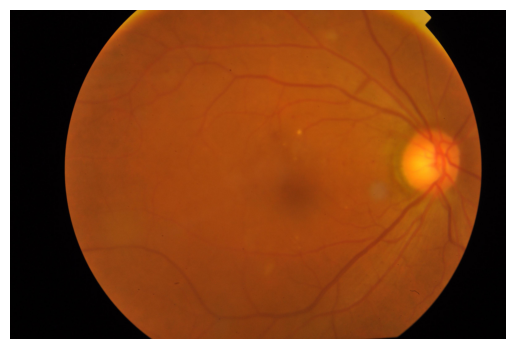

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(train_df.loc[0, "file_path"])

plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
#Create the PyTorch Dataset

In [14]:
# ============================================================
# Step 6: Custom Dataset
# ============================================================

from torch.utils.data import Dataset
from PIL import Image

class APTOSDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "file_path"]
        label = int(self.df.loc[idx, "diagnosis"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [16]:
train_dataset = APTOSDataset(
    train_df,
    transform=train_transform
)

valid_dataset = APTOSDataset(
    valid_df,
    transform=valid_transform
)

print(len(train_dataset))
print(len(valid_dataset))

2930
366


In [17]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
2


In [18]:
# ============================================================
# Step 10: DataLoaders
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")

Train batches: 92
Validation batches: 12


In [19]:
#Step 11: Verify the DataLoader

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([2, 0, 0, 0, 2, 0, 3, 0, 2, 0, 0, 3, 0, 4, 2, 0, 4, 3, 2, 0, 3, 4, 0, 1,
        0, 3, 2, 0, 0, 2, 4, 2])


In [20]:
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=5
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [21]:
#Step 12: Configure the Device

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [22]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [23]:
#Step 13: Move the Model to GPU

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [24]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU capability:", torch.cuda.get_device_capability(0))

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4
GPU capability: (7, 5)


In [25]:
import torch

device = torch.device("cuda")

x = torch.randn(2, 2).to(device)
print(x)

tensor([[ 0.8858, -0.0554],
        [-1.1062, -0.1468]], device='cuda:0')


In [26]:
#Step 14: Define the Loss Function

import torch.nn as nn

criterion = nn.CrossEntropyLoss()

#Step 15: Define the Optimizer

import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

#Step 16: Learning Rate Scheduler

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

#Step 17: Quick Forward Pass

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 5])


In [27]:
# ============================================================
# Step 18: Training and Validation Functions
# ============================================================

from tqdm.auto import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(
            loss=loss.item(),
            acc=100 * correct / total
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

In [28]:
# ============================================================
# Training Configuration
# ============================================================

EPOCHS = 15

best_accuracy = 0.0

train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []

In [29]:
# ============================================================
# Main Training Loop
# ============================================================

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*40)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_acc, y_true, y_pred = validate(
        model,
        valid_loader,
        criterion,
        device
    )

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Valid Acc  : {valid_acc:.4f}")

    if valid_acc > best_accuracy:

        best_accuracy = valid_acc

        torch.save(
            model.state_dict(),
            "best_vit_model.pth"
        )

        print("✅ Best model saved!")

print("\nTraining Complete!")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")


Epoch 1/15
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss : 0.7766
Train Acc  : 0.7099
Valid Loss : 0.5769
Valid Acc  : 0.7842
✅ Best model saved!

Epoch 2/15
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss : 0.5514
Train Acc  : 0.7874
Valid Loss : 0.5170
Valid Acc  : 0.8005
✅ Best model saved!

Epoch 3/15
----------------------------------------


...

Train Loss : 0.1509
Train Acc  : 0.9461
Valid Loss : 0.4619
Valid Acc  : 0.8579

Epoch 14/15
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss : 0.1671
Train Acc  : 0.9399
Valid Loss : 0.4644
Valid Acc  : 0.8607

Epoch 15/15
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss : 0.1944
Train Acc  : 0.9287
Valid Loss : 0.4862
Valid Acc  : 0.8579

Training Complete!
Best Validation Accuracy: 0.8607


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

VALIDATION SET — EVALUATION SUMMARY (Vision Transformer)
Accuracy               : 0.8607
Precision (weighted)   : 0.8566
Recall (weighted)      : 0.8607
F1-Score (weighted)    : 0.8581
Quadratic Weighted Kappa (QWK): 0.9081

Classification Report:

                  precision    recall  f1-score   support

           No DR       0.98      0.99      0.99       172
            Mild       0.75      0.75      0.75        40
        Moderate       0.80      0.81      0.80       104
          Severe       0.59      0.45      0.51        22
Proliferative DR       0.69      0.71      0.70        28

        accuracy                           0.86       366
       macro avg       0.76      0.74      0.75       366
    weighted avg       0.86      0.86      0.86       366



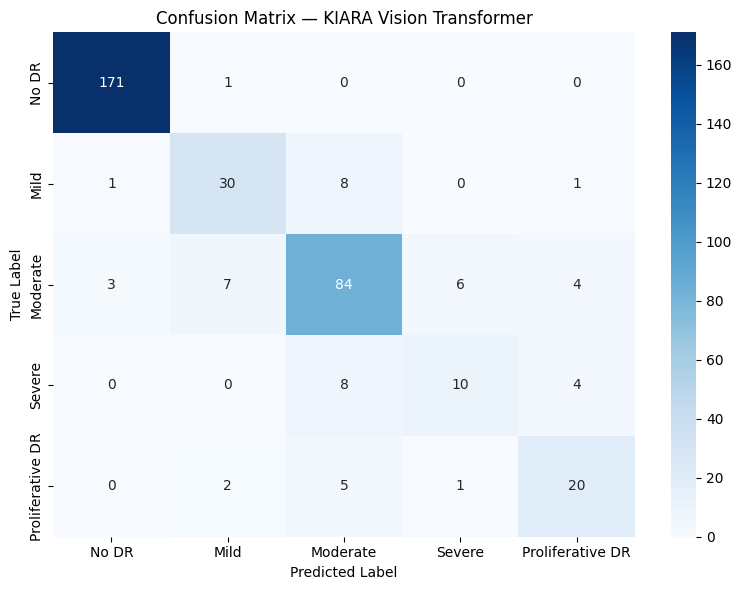

In [30]:
# 12. Comprehensive Evaluation
CLASS_NAMES = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}
NUM_CLASSES = 5

model.load_state_dict(torch.load("best_vit_model.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print("=" * 55)
print("VALIDATION SET — EVALUATION SUMMARY (Vision Transformer)")
print("=" * 55)
print(f"Accuracy               : {acc:.4f}")
print(f"Precision (weighted)   : {precision:.4f}")
print(f"Recall (weighted)      : {recall:.4f}")
print(f"F1-Score (weighted)    : {f1:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print("=" * 55)

print("\nClassification Report:\n")
print(classification_report(
    all_labels, all_preds,
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    zero_division=0,
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — KIARA Vision Transformer")
plt.tight_layout()
plt.show()

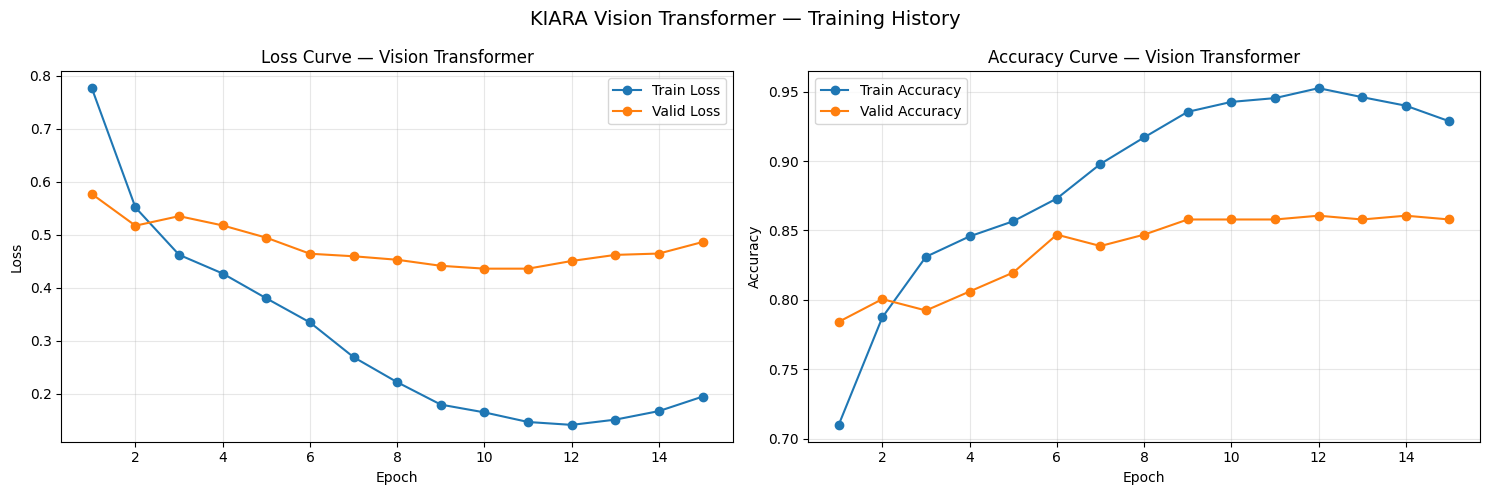

In [31]:
# 13. Training Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, valid_losses, label="Valid Loss", marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve — Vision Transformer")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accuracies, label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, valid_accuracies, label="Valid Accuracy", marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve — Vision Transformer")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("KIARA Vision Transformer — Training History", fontsize=14)
plt.tight_layout()
plt.show()

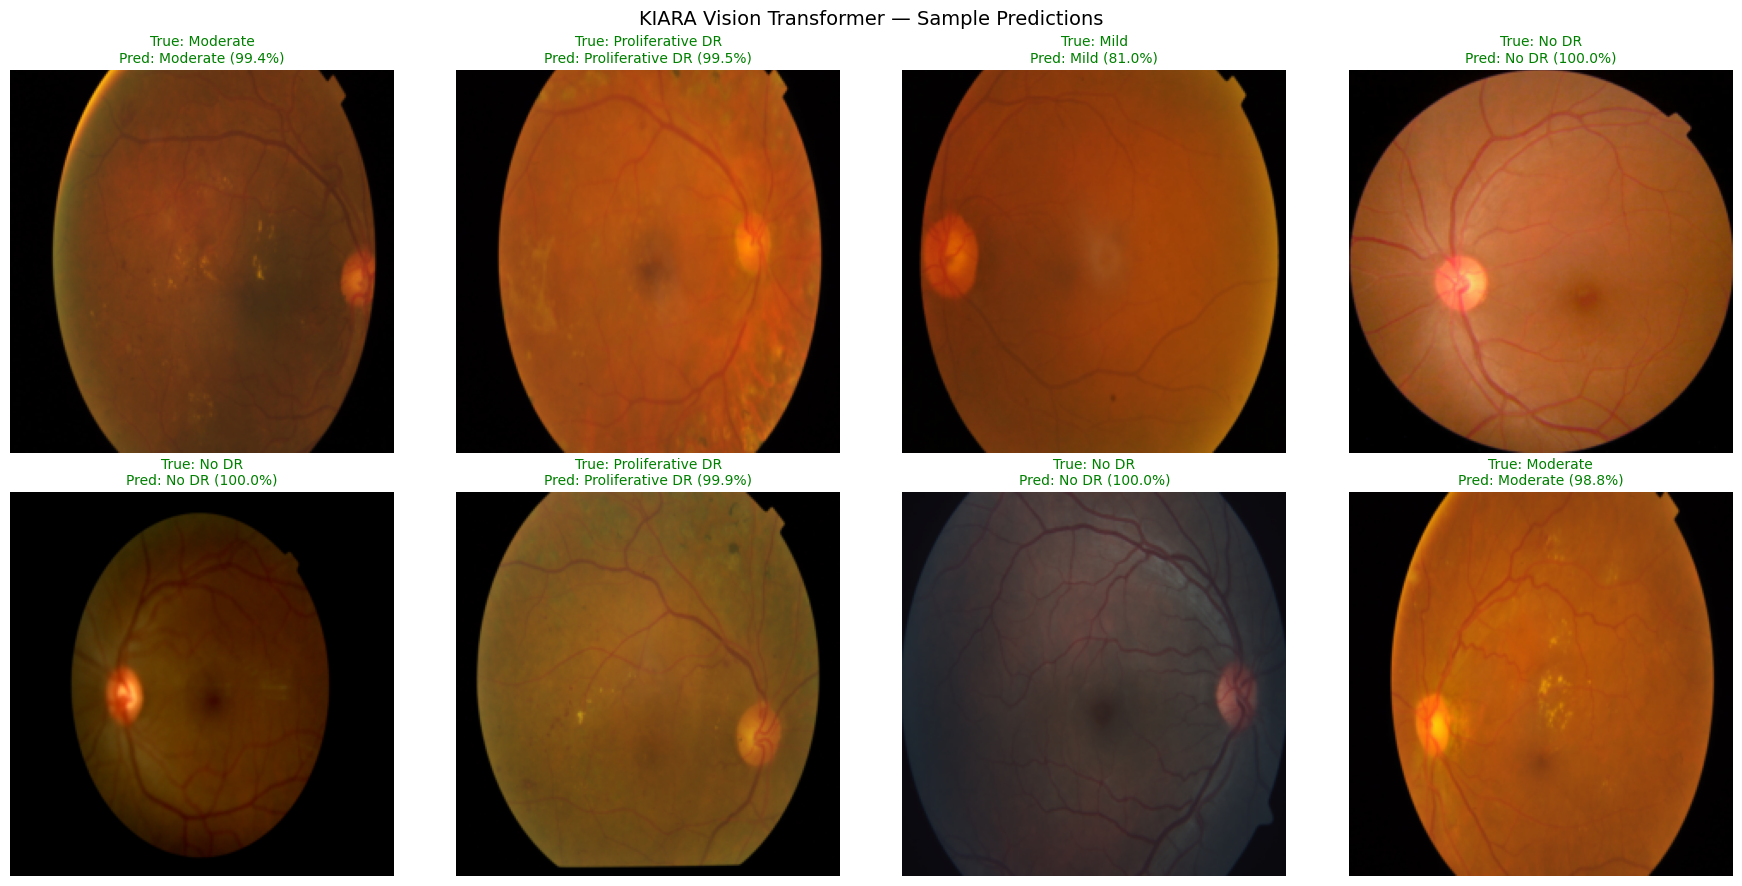

In [32]:
# 14. Prediction Visualization
def denormalize(tensor_img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

vis_images, vis_labels = next(iter(valid_loader))
vis_images_device = vis_images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(vis_images_device)
    probs = torch.softmax(outputs, dim=1)
    confidences, preds = torch.max(probs, dim=1)

n_display = min(8, len(vis_images))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i in range(n_display):
    img = denormalize(vis_images[i])
    true_label = vis_labels[i].item()
    pred_label = preds[i].item()
    confidence = confidences[i].item()
    color = "green" if true_label == pred_label else "red"

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({confidence*100:.1f}%)",
        color=color, fontsize=10,
    )

plt.suptitle("KIARA Vision Transformer — Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
# 15. Final model
FINAL_MODEL_PATH = "kiara_vit_final.pth"
torch.save(model.state_dict(), FINAL_MODEL_PATH)

torch.save({
    "model_state_dict": model.state_dict(),
    "model_name": "vit_base_patch16_224",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std": [0.229, 0.224, 0.225],
    "best_val_accuracy": float(best_accuracy),
    "qwk": float(qwk),
}, "kiara_vit_checkpoint.pth")

print(f"Final model weights saved to : {FINAL_MODEL_PATH}")
print("Rich checkpoint saved to      : kiara_vit_checkpoint.pth")

Final model weights saved to : kiara_vit_final.pth
Rich checkpoint saved to      : kiara_vit_checkpoint.pth
